# Assignment 8

## VAEs and Normalizing Flows

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-05-XX

Course: Deep Machine Learning 4DT908

## Variational Inference using VAEs and Normalizing Flows

### Setting the Scene

In this assignment, we implement a vanilla VAE from scratch and train it on grayscale images of the MNIST handwritten digits dataset.
Then, we train the same model but use a Normalizing Flow as variational distribution to approximate the true posterior.

For the (vanilla) VAE:

- Suggest one final version that uses dense-layers only *or* convolution/de-convolution.
- Assume a standard normal prior belief.
- Use a diagonal Gaussion as variational distribution.
- As reconstruction loss, choose between MSE and BCE.
- If necessary, implement it as a $\beta$-VAE that allows you to put an (adaptive) weight on the KL-divergence.

Much like the previous assignment, you shall fill out the blanks, answer the questions, and evaluate and compare your trained models.
However, we will not be implementing Normalizing Flows, due to the complexity of bijectors, conditioners, and other required coupling blocks.
Instead, you shall use a library/framework.

Suggested are these 2:

- PyTorch: Use the `normflows` package: <https://github.com/VincentStimper/normalizing-flows> (preferred)
- JAX: Use the `pzflow` package: <https://github.com/jfcrenshaw/pzflow>

It is acceptable to use something else, but make sure you can integrate it nicely into your VAE implementation.
As for the NF model itself:

- Use a diagonal Gaussian base distribution 
- Try to keep the model relatively shallow (less than ca. ten blocks)
- Attempt to use as few as possible parameters in the conditioners


## <u>Make a Choice!</u>

- Choose between a dense or convolutional architecture for your encoder/decoder (don't mix).
- Use the same architecture for encoder/decoder in the vanilla and NF-backed VAE to keep it fair.
- Keep the KL-$\beta$ in the range $[2,5]$ -- but don't change between models, chose one for both.

### If you choose Dense

Limits:
- Bottleneck = 3
- Total params encoder + decoder = 400k

### If you choose Convolutional

Limits:
- Bottleneck = 5
- Total params encoder + decoder = 200k

## Part 1: Implement your own VAE

### Recap: Variational Bayes

In our first lecture and assignment, we took a Bayesian variational approach to **quantify uncertainty** in our model's parameters.
Let's call this **Scenario A**.

In **A**,
- we have a polynomial with a handful of parameters.
- Our prior belief over these parameters $p(\mathbf{w})=\mathcal{N}(0,I)$.
- The true posterior, $p(\mathbf{w}\vert\mathbf{X},\mathbf{y})$, is approximated using a mean-field variational distribution. Our choise was a diagonal Gaussian: $q_{\phi}(\mathbf{w})=\mathcal{N}(\mu_{\phi},\Sigma_{\phi})$.
- The ELBO was: $\text{ELBO}=\mathbb{E}_{q_{\phi}(\mathbf{w})}\left[\log{(p(\mathbf{y}|\mathbf{X},\mathbf{w}))}\right]-D_{\text{KL}}\left(q_{\phi}(\mathbf{w})\|p(\mathbf{w})\right)$.
- The Monte Carlo approximation of the ELBO is: $\text{ELBO}(\phi)\approx\frac{1}{S}\sum_{s=1}^{S}\,\underbrace{\left[\sum_{i=1}^{N}\,\log{(p(y_i|x_i,w^{(s)}))}\right]}_{\text{log-sum of i.i.d. observations}}-\underbrace{\left[\log{\left(q_{\mu,\sigma}\left(w^{(s)}\right)\right)}-\log{\left(p\left(w^{(s)}\right)\right)}\right]}_{\text{MC-approx. of KL-divergence}}$.


So, in order to introduce variation, we insert randomness into our model using the reparameterization trick.
Since we optimize the current $\mu,\sigma$ of our variational distribution, it needs to be differentiable w.r.t. those parameters.
Recall that $w=\mu+\sigma\cdot\epsilon$.
So, in order to average the effect of many different $w^{(s)}\in W$, we compute the mean of our model's predictions using these varying parameters.
Then, we maximize the average ELBO.

### Differences in a Variational Autoencoder

Now, in a vanilla variational autoencoder (VAE), we **quantify uncertainty in the latent variables, per individial observation**.
Here, we will make use of so-called **amortized inference**.

A VAE has these components:
- An **Encoder** Network.
    * Takes the input data and predicts, for **each** observation $x_i\in\mathbf{X}$, the parameters of our approximate posterior $q_{\phi}(\mathbf{Z}|\mathbf{X})=\mathcal{N}(\mathbf{Z}, \mathbf{\mu}_{\phi}(\mathbf{X}),\Sigma_{\phi}(\mathbf{X}))$.
    * The conditional prediction (per observation) of the variational parameters is called amortized inference.
    * If our latent dimension is 20, for example, then we would need to predict 20 means and 20 variances, per observation.
    * The reparameterization trick lies in constructing $z=\mu+\sigma\cdot\epsilon$ for an epsilon drawn from a standard normal. Then, it is this $z$ that gets decoded.
- A set of latent variables (denoted $\mathbf{Z}$). Usually the dimensionality of $\mathbf{Z}$ is lower than that of the input, $X$.
- A **Decoder** Network.
    * Given $\mathbf{Z}$, learns to predict a reconstructed $\mathbf{X}'\approx\mathbf{X}$.

<pre>
Input X --> Encoder Network (phi)  --> Latent variables Z ~ q_{phi}(Z|X) -->
    Decoder Network (theta)  -->  Reconstructed X (X').
</pre>

Notice how our **prior** belief relates now to hoe each $z_i$ is distributed.
Again, here we will assume $p(\mathbf{Z})\sim\mathcal{N}(0,I)$.
During training, we will minimize again the Kullback-Leibler divergence between this prior belief and our mean-field approximation:

$$
\begin{align}
    D_{\text{KL}}\left(q_{\phi}(z|x)\,\|\,p(z)\right)
\end{align}
$$

for **each** observation $x$.
If we now add a reconstruction term, it will constitute the ELBO loss.
Since each observation constitutes itw own Gaussian in latent space, $q_{\phi}(z|x)$ differs for each x.
Therefore, only the **aggregate** distribution $q_{\phi}(z)$ matches the prior.
The encoder network naturally shares (has the same set of) parameters across all observations, making it generalize to the dataset.

### Implementation

The following is a skeleton for a PyTorch-based implementation.

You may or may not follow this skeleton, it is just a suggestion.

Choose one architecture that works best for you (dense <u>**or**</u> convolutional).

In [13]:
import torch
from torch import nn, Tensor
from torch.distributions.normal import Normal


class MyVAE(nn.Module):
    """
    A vanilla VAE with standard normal prior belief and normal independent variational
    distribution. Has a configurable latent size.
    """

    def __init__(self, dim: int, dim_z: int = 3, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.dim = dim
        self.dim_z = dim_z

        hidden_1 = 192
        hidden_2 = 96

        self.encoder = nn.Sequential(
            nn.Linear(dim, hidden_1),
            nn.LayerNorm(hidden_1),
            nn.GELU(),
            nn.Linear(hidden_1, hidden_2),
            nn.LayerNorm(hidden_2),
            nn.GELU(),
        )
        self.mu_layer = nn.Linear(hidden_2, dim_z)
        self.logvar_layer = nn.Linear(hidden_2, dim_z)

        self.decoder = nn.Sequential(
            nn.Linear(dim_z, hidden_2),
            nn.GELU(),
            nn.Linear(hidden_2, hidden_1),
            nn.GELU(),
            nn.Linear(hidden_1, dim),
            nn.Sigmoid(),
        )

        self.register_buffer("prior_loc", torch.zeros(dim_z))
        self.register_buffer("prior_scale", torch.ones(dim_z))

    @property
    def prior(self) -> Normal:
        return Normal(self.prior_loc, self.prior_scale)

    def encode(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """Encodes the input and returns the mus and variances."""
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)

        return mu, logvar

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        """
        Takes the original input, encodes it, applies the R-trick,
        reconstructs the inputs, and calculates the KL-divergence.
        Returns the reconstruction and the divergence.
        """
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        x_recon = self.decoder(z)
        q = Normal(mu, std)
        kl = torch.distributions.kl_divergence(q, self.prior).sum(dim=1).mean()

        return x_recon, kl, z

    def sample(self, n: int) -> Tensor:
        """Sample from the trained model using the unconditional prior."""
        z = self.prior.sample((n,))

        return self.decoder(z)

## Part 2: Enhance VAE with a Normalizing Flow

When we change our the variational distribution of a VAE to be a Normalizing Flow, we still use the same ELBO.
But things change a little, because we kind of use the flow "backwards":

1. The encoder, as before, outputs variational parameters $\mu$ and $\sigma$, conditioned (*amortized*) on the input $x$.
2. We will assume a standard normal factorized Gaussian as the NF's base distribution.
    * However, instead of parameterizing it directly and sampling from it, we have to apply the reparameterization trick again.
    * It is simpler to just sample from a standard normal isotropic Gaussian and construct $z_0=\mu+\sigma\cdot\epsilon$.
3. $z_0$ enters the flow.
    * Through a series of $K$ transformations, it becomes $z_K=T_K\circ T_{K-1}\circ\dots\circ T_1(z_0)$.
    * The variational distribution is now $q_{\phi}(z_K\vert x)$.
4. $z_K$ is now fed into the decoder, that is, $x'\sim p_{\theta}(x\vert z_K)$, which shall reconstruct the original inputs $x$.


----

Since we assume a diagonal normal as base distribution for our normalizing flow here ($\psi$), the change-of-variables formula is defined as:

$$
\begin{align}
    q_{\phi}(z_K\vert x)=\psi_{\phi}(z_0)\,\left\lvert\operatorname{det}\frac{\partial\,z_0}{\partial\,z_K}\right\rvert=\psi_{\phi}(z_0)\prod_{k=1}^{K}\,\left\lvert\operatorname{det}\frac{\partial\,z_{k-1}}{\partial\,z_k}\right\rvert.
\end{align}
$$

----

### Define the Flow Model

Below is some boilerplate code for constructing a Normalizing Flow using the `normflows` package.
Even if you choose something else, perhaps you want to conceptually construct your flow similar to how it's done here.

In [14]:
from normflows import NormalizingFlow
from normflows.flows import Flow, CoupledRationalQuadraticSpline, LULinearPermute
from typing import override


def make_flows(dim: int, K: int, units: int = 64, layers: int = 2) -> list[Flow]:
    """Repeats a sequence of pre-defined coupling blocks K times."""
    flows: list[Flow] = []
    for _ in range(K):
        flows.append(
            CoupledRationalQuadraticSpline(
                num_input_channels=dim, num_blocks=layers, num_hidden_channels=units
            )
        )
        flows.append(LULinearPermute(num_channels=dim))

    return flows


class MyVAEwithNF(MyVAE):
    @override
    def __init__(self, K: int, dim: int, dim_z: int, *args, **kwargs):
        super().__init__(dim=dim, dim_z=dim_z, *args, **kwargs)

        self.flow = NormalizingFlow(
            q0=Normal(torch.zeros(dim_z), torch.ones(dim_z)), flows=make_flows(dim_z, K)
        )

    @override
    def sample(self, n: int) -> Tensor:
        """Draw unconditional samples (z_0), pass them through the flow (z_K), then decode."""
        z_0 = self.flow.q0.sample((n,))
        z = self.flow.forward(z_0)

        return self.decoder(z)

    @override
    def forward(self, x: Tensor) -> tuple[Tensor, Tensor, Tensor]:
        """Returns the reconstruction and KL-divergence."""
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z_0 = mu + std * eps

        z, log_det = z_0, 0.0
        for flow in self.flow.flows:
            z, ld = flow(z)
            log_det += ld
        z_K = z

        log_qz0 = Normal(mu, std).log_prob(z_0).sum(dim=1)
        log_pzK = self.prior.log_prob(z_K).sum(dim=1)

        kl = (log_qz0 - log_pzK - log_det).mean()

        x_recon = self.decoder(z_K)

        return x_recon, kl, z_K

## Training

We will train on grayscale MNIST handwritten digits.
The goal is to train either architecture and then to compare the results.

### Download and Prepare the Data

In [15]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 64

transform = transforms.Compose([transforms.ToTensor()])

# Download and load MNIST training set
train_dataset = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size, drop_last=True, shuffle=True
)

# Load MNIST test set
test_dataset = datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)
test_loader = DataLoader(
    dataset=test_dataset, batch_size=batch_size, drop_last=True, shuffle=False
)

In [16]:
train_dataset.data.shape, test_dataset.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

### Using ELBO

Recall that the ELBO is essentially the expectation of the log-likelihood of the data under our currently parameterized model minus the KL-divergence of the variational distribution and the prior belief.

Recall that the (log-)likelihood function does not have to be a proper probability density.
Instead, it should yield values that allow relative comparisons on how well the certain parameters represent our data.
Here, $f_{\theta}$ represents our decoder that reconstructs the inputs, i.e., $f\mapsto X'$.

$$
\begin{align}
    \text{ELBO}(\theta,\phi;x)=\mathbb{E}_{q_{\phi}(z|x)}\left[-\text{reconstruction loss}\left(x,f_{\theta}(z)\right)\right]-D_{\text{KL}}\left(q_{\phi}(z|x)\,\|\,p(z)\right)\nonumber.
\end{align}
$$


In a VAE, we typically have a reconstruction loss like MSE.
We can just plug it into the expectation and use it as our likelihood.
Then, we negate the ELBO to obtain our loss objective $\mathcal{J}$ for minimization:

$$
\begin{align}
    \operatorname{MSE}\left(x,\mu_{\theta}(z)\right)&=\left\|x-\mu_{\theta}(z)\right\|^2,\nonumber
    \\[1em]
    \mathcal{J}(\theta,\phi;x)&=\underbrace{\mathbb{E}_{q_{\phi}(z|x)}\left[\left\|x-\mu_{\theta}(z)\right\|^2\right]}_{\text{expected (mean) reconstr. error}} + D_{\text{KL}}\left(q_{\phi}(z|x)\,\|\,p(z)\right)\nonumber.
\end{align}
$$

### The Vanilla VAE

Let's train this model first.
It is perhaps easiest to use the same training routine for either model (with/without NF).

In [17]:
import numpy as np
from torch import device
from torch.optim import Adam
from torch.nn.functional import binary_cross_entropy
from torch.nn.utils import clip_grad_norm_
import random

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

DEVICE = device("cuda" if torch.cuda.is_available() else "cpu")
DIM_Z = 3
LEARNING_RATE = 5e-4
EPOCHS = 10
KL_DIV_BETA = 3.0

# Dense configuration (bottleneck=3, total encoder+decoder params < 400k).
model = MyVAE(dim=np.prod(train_dataset.data.shape[1:]).item(), dim_z=DIM_Z).to(
    device=DEVICE
)
optim = Adam(params=model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters in MyVAE: {total_params:,}")

recon_losses = []
kl_divs = []

for epoch in range(EPOCHS):
    model.train()
    epoch_recon = 0
    epoch_kl = 0

    for batch in train_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to(DEVICE)

        x_recon, kl_div, _ = model(x)
        recon_loss = binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
        loss = recon_loss + KL_DIV_BETA * kl_div

        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=5.0)
        optim.step()

        epoch_recon += recon_loss.item()
        epoch_kl += kl_div.item()

    recon_losses.append(epoch_recon / len(train_loader))
    kl_divs.append(epoch_kl / len(train_loader))
    print(
        f"Epoch: {epoch+1}, Recon Loss: {recon_losses[-1]:.4f}, KL: {kl_divs[-1]:.4f}"
    )

Total parameters in MyVAE: 340,726
Epoch: 1, Recon Loss: 187.5920, KL: 3.6409
Epoch: 2, Recon Loss: 150.8379, KL: 4.6547
Epoch: 3, Recon Loss: 144.6525, KL: 5.0516
Epoch: 4, Recon Loss: 141.2907, KL: 5.2719
Epoch: 5, Recon Loss: 138.8845, KL: 5.4360
Epoch: 6, Recon Loss: 136.9524, KL: 5.5791
Epoch: 7, Recon Loss: 135.3406, KL: 5.6844
Epoch: 8, Recon Loss: 134.0665, KL: 5.7755
Epoch: 9, Recon Loss: 133.0240, KL: 5.8511
Epoch: 10, Recon Loss: 132.1208, KL: 5.9158


#### Evaluation

<u>Please provide **4** kinds of plots now:</u>

1. Training progress. Show the reconstruction loss and KL-divergence separately.
2. "Animation" of the latent space. For example, draw a sample from your prior belief and gradually manipulate it along a single dimension (keep others constant) to demonstrate what this dimensions has effectively learned.
3. Draw at least 25 random samples using your prior belief from the trained model.
4. Use the trained model to encode all the images from the holdout dataset. Further reduce the dimensionality to 2 using TSNE and plot the results


**Question**: For the second plot: What did any of the latent dimensions learned? What happens when you animate a single dimension between, say, `[-3,3]`?

**Question**: What is your qualitative evaluation of the samples from the 3rd plot?

**Question**: What is your interpretation of the 4th plot? Has the model learned something useful?

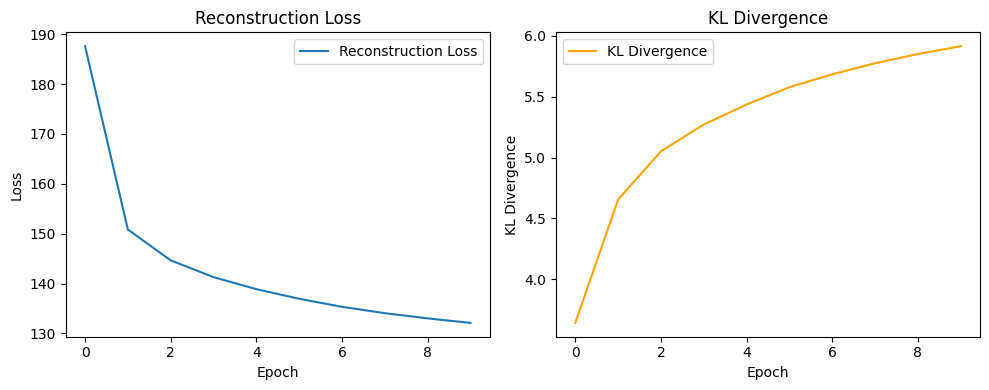

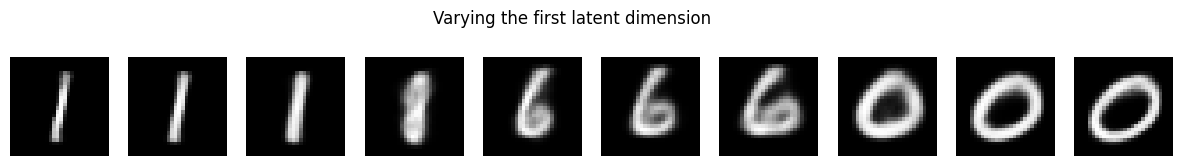

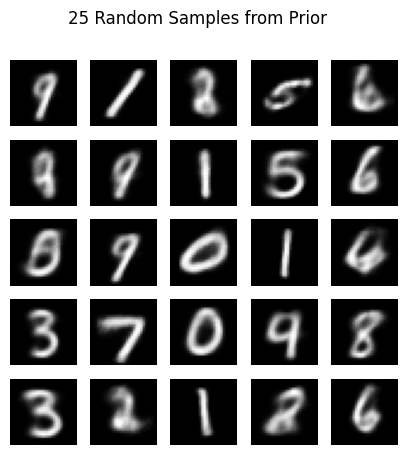

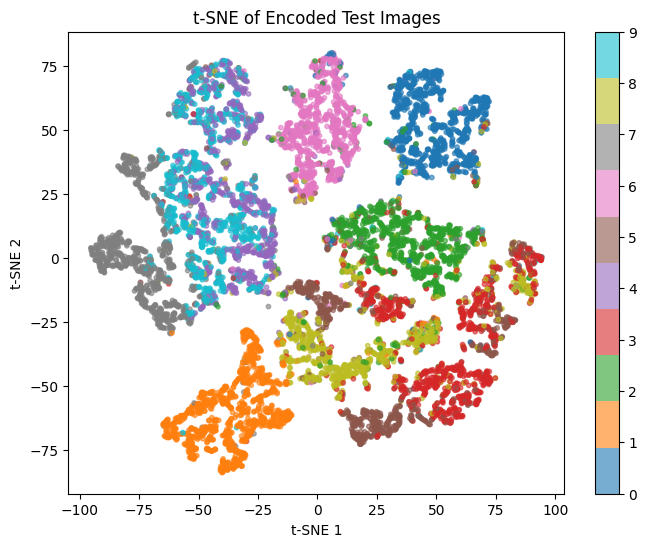

In [18]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(recon_losses, label="Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reconstruction Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(kl_divs, label="KL Divergence", color="orange")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("KL Divergence")
plt.legend()
plt.tight_layout()
plt.show()

n_steps = 10
z = torch.zeros((n_steps, DIM_Z)).to(DEVICE)
values = torch.linspace(-3, 3, n_steps)
for i, val in enumerate(values):
    z[i, 0] = val
with torch.no_grad():
    samples = model.decoder(z).cpu().numpy()
plt.figure(figsize=(15, 2))
for i, img in enumerate(samples):
    plt.subplot(1, n_steps, i + 1)
    plt.imshow(img.reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Varying the first latent dimension")
plt.show()

with torch.no_grad():
    prior_samples = model.sample(25).cpu().numpy()
plt.figure(figsize=(5, 5))
for i, img in enumerate(prior_samples):
    plt.subplot(5, 5, i + 1)
    plt.imshow(img.reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("25 Random Samples from Prior")
plt.show()

all_z = []
all_labels = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE).view(x.size(0), -1)
        mu, _ = model.encode(x)
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())
all_z = np.concatenate(all_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
tsne = TSNE(n_components=2, random_state=42)
z2d = tsne.fit_transform(all_z)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(z2d[:, 0], z2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE of Encoded Test Images")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

##### Answers for questions

1. The latent traversal is smooth and coherent: changing only one latent coordinate gradually changes writing style and stroke thickness instead of abruptly switching class. This indicates that the first latent variable captures a meaningful factor of variation.

2. Prior samples are mostly recognizable digits with moderate blur in ambiguous cases. This is expected for a compact bottleneck (`dim_z=3`) and shows the decoder has learned a stable mapping from latent space to the image manifold.

3. The t-SNE view forms mostly distinct class regions with some overlap between visually similar digits. That pattern is consistent with useful but not perfectly class-separable latent features, which is appropriate for an unsupervised objective.


### The NF-backed VAE

The ELBO stays the exact same.
However, we have to plug in our more flexible variational distribution (which is calculated using the NF's chosen base-distribution and the determinant of the transformation).

Recall that ($z_0$ being the output of the encoder):

$$
\begin{align}
    q_{\phi}(z_K\vert x)&=\psi_{\phi}(z_0)\,\left\lvert\operatorname{det}\frac{\partial\,z_0}{\partial\,z_K}\right\rvert=\psi_{\phi}(z_0)\prod_{k=1}^{K}\,\left\lvert\operatorname{det}\frac{\partial\,z_{k-1}}{\partial\,z_k}\right\rvert.
    \\[1em]
    \log{\left(q_{\phi}(z_K\vert x)\right)}&=\log{\left(\psi_{\phi}(z_0)\right)} + \underbrace{\log{\left(\left\lvert\operatorname{det}\frac{\partial\,z_0}{\partial\,z_K}\right\rvert\right)}}_{\text{the "logabsdet"}}=\log{\left(\psi_{\phi}(z_0)\right)}+\sum_{k=1}^{K}\,\log{\left(\left\lvert\operatorname{det}\frac{\partial\,z_{k-1}}{\partial\,z_k}\right\rvert\right)}.

\end{align}
$$


$$
\begin{align}
    \text{ELBO}(\theta,\phi;x)&=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}\right]-D_{\text{KL}}\left[q_{\phi}(z\vert x)\,\|\,p(z)\right],
    \\[1em]
    &=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}\right]-\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(\frac{q_{\phi}(z_K\vert x)}{p(z_K)}\right)}\right],
    \\[1em]
    &=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}\right]-\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\underbrace{\log{\left(\psi_{\phi}(z_0)\right)-\sum_{k=1}^{K}\,\log{\left\lvert\operatorname{det}\frac{\partial\,z_k}{\partial\,z_{k-1}}\right\rvert}}}_{q_{\phi}(z_K\vert x)}-\log{\left(p(z_K)\right)}\right],
    \\[3em]
    \text{Notice that}&\text{ numerator and denominator in the determinant (and its sign) have flipped! (see below)}\nonumber
    \\[1em]
    &=\mathbb{E}_{q_{\phi}(z_K\vert x)}\left[\log{\left(p_{\theta}(z_K\vert x)\right)}-\log{\left(\psi_{\phi}(z_0)\right)+\sum_{k=1}^{K}\,\log{\left\lvert\operatorname{det}\frac{\partial\,z_k}{\partial\,z_{k-1}}\right\rvert}}+\log{\left(p(z_K)\right)}\right]
    \\[2em]
    \text{Notice that}&\text{ the Monte Carlo approximation for $l$ samples becomes:}\nonumber
    \\[1em]
    &\approx\frac{1}{L}\sum_{l=1}^{L}\,\left(-\mathcal{R}\left(x,z_K^{(l)};\theta\right)\right)-\log{\left(\psi_{\phi}\left(z_0^{(l)}\right)\right)+\sum_{k=1}^{K}\,\log{\left\lvert\operatorname{det}\frac{\partial\,z_k^{(l)}}{\partial\,z_{k-1}^{(l)}}\right\rvert}}+\log{\left(p\left(z_K^{(l)}\right)\right)}.
    \\[2em]
    \text{Notice that}&\text{ $\mathcal{R}$ is the reconstruction loss.}\nonumber
\end{align}
$$

The fraction of computing the determinant flips according to the logarithm laws (determinants satisfy precisely the reciprocal relationship $\operatorname{det}(\frac{a}{b})=\left(\operatorname{det}\frac{b}{a}\right)^{-1}$).

Therefore, we have $\log{\left\lvert\operatorname{det}(a/b)\right\rvert}=-\log{\left\lvert\operatorname{det}(b/a)\right\rvert}$.
We have to flip it because usually we would transform $z_0$ to $z_K$, giving us the determinant for that transformation.
However, to evaluate the log-likelihood of $z_0$, we require the determinant from the inverse transformation!
Therefore, we have to subtract its reciprocal instead.

The NF-backed VAE in a nutshell:

- $x\mapsto z_0$
    * Use the encoder and reparameterization trick to produce $z_0$.
- $z_0\mapsto z_K$
    * For a discrete normalizing flow with $K$ transformations.
- $z_K\mapsto\approx x$
    * Use the decoder to reconstruct the original $x\approx x'$.

#### Training

Here, train your NF-backed VAE with the optimal parameters found by you.

In order to get comparable results, do **not** alter the number of latent dimensions.

In [19]:
LEARNING_RATE = 5e-4
EPOCHS = 10
KL_DIV_BETA = 3.0

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

model = MyVAEwithNF(
    K=6, dim=np.prod(train_dataset.data.shape[1:]).item(), dim_z=DIM_Z
).to(device=DEVICE)
model.beta = KL_DIV_BETA
optim = Adam(params=model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters in MyVAEwithNF: {total_params:,}")

recon_losses_nf = []
kl_divs_nf = []

for epoch in range(EPOCHS):
    model.train()
    epoch_recon = 0
    epoch_kl = 0

    for batch in train_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to(DEVICE)

        x_recon, kl_div, _ = model(x)
        recon_loss = binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
        loss = recon_loss + KL_DIV_BETA * kl_div

        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=5.0)
        optim.step()

        epoch_recon += recon_loss.item()
        epoch_kl += kl_div.item()

    recon_losses_nf.append(epoch_recon / len(train_loader))
    kl_divs_nf.append(epoch_kl / len(train_loader))
    print(
        f"Epoch: {epoch+1}, Recon Loss: {recon_losses_nf[-1]:.4f}, KL: {kl_divs_nf[-1]:.4f}"
    )

Total parameters in MyVAEwithNF: 451,036
Epoch: 1, Recon Loss: 185.8505, KL: 3.5389
Epoch: 2, Recon Loss: 149.5651, KL: 4.7436
Epoch: 3, Recon Loss: 142.0566, KL: 5.1956
Epoch: 4, Recon Loss: 138.6547, KL: 5.3978
Epoch: 5, Recon Loss: 136.4669, KL: 5.5411
Epoch: 6, Recon Loss: 134.9018, KL: 5.6485
Epoch: 7, Recon Loss: 133.7077, KL: 5.7339
Epoch: 8, Recon Loss: 132.7618, KL: 5.8043
Epoch: 9, Recon Loss: 131.9087, KL: 5.8664
Epoch: 10, Recon Loss: 131.1929, KL: 5.9193


#### Evaluation

Conduct the exact same evaluation as you did for the vanilla VAE.
<u>Produce the same kind of plots and answer the same questions **again**!</u>

**Another Question**: Which model is better? How did you measure this and come to that conclusion?

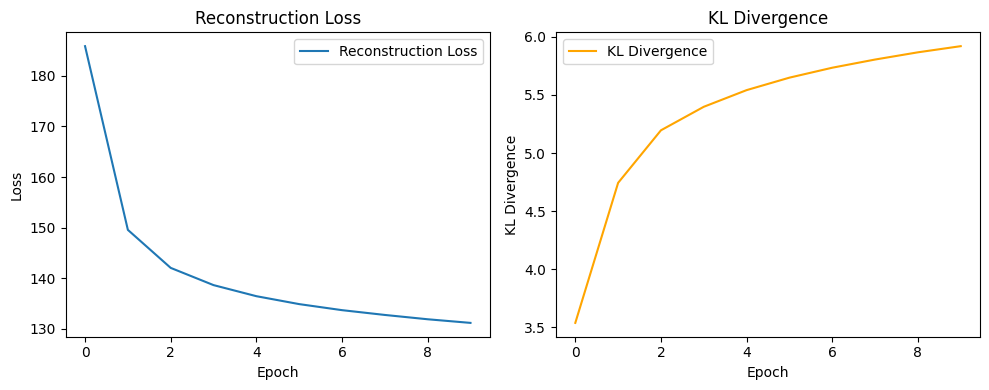

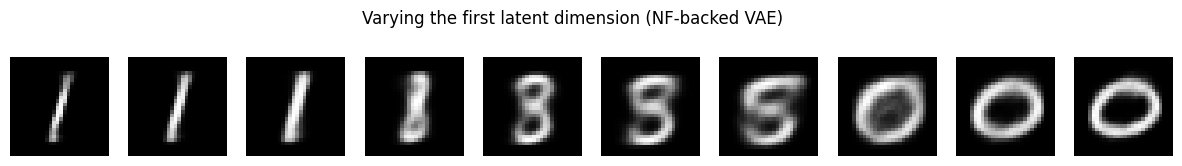

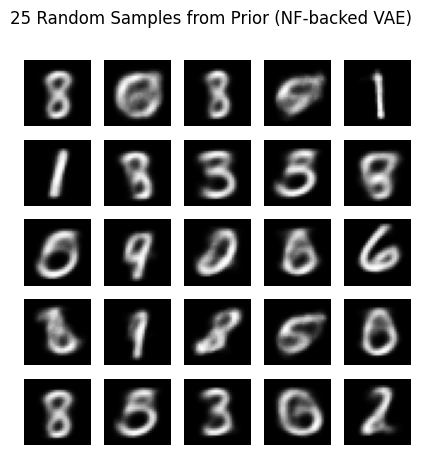

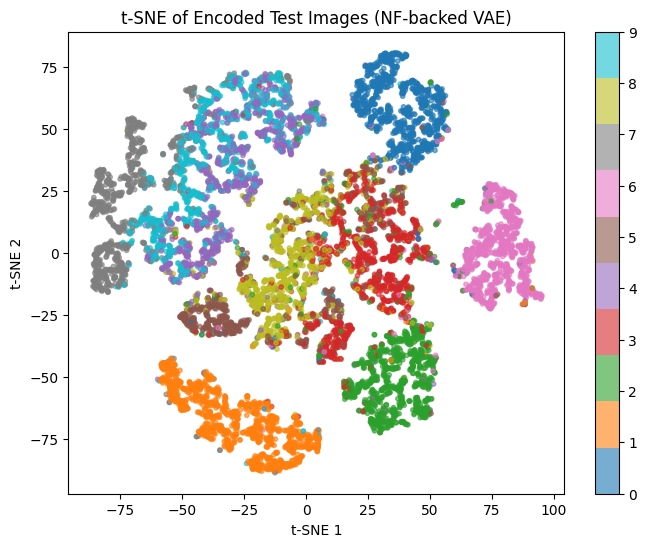

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(recon_losses_nf, label="Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reconstruction Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(kl_divs_nf, label="KL Divergence", color="orange")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("KL Divergence")
plt.legend()
plt.tight_layout()
plt.show()

z = torch.zeros((n_steps, DIM_Z)).to(DEVICE)
values = torch.linspace(-3, 3, n_steps)
for i, val in enumerate(values):
    z[i, 0] = val
with torch.no_grad():
    samples = model.decoder(z).cpu().numpy()
plt.figure(figsize=(15, 2))
for i, img in enumerate(samples):
    plt.subplot(1, n_steps, i + 1)
    plt.imshow(img.reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Varying the first latent dimension (NF-backed VAE)")
plt.show()

with torch.no_grad():
    prior_samples = model.sample(25).cpu().numpy()
plt.figure(figsize=(5, 5))
for i, img in enumerate(prior_samples):
    plt.subplot(5, 5, i + 1)
    plt.imshow(img.reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("25 Random Samples from Prior (NF-backed VAE)")
plt.show()

all_z = []
all_labels = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE).view(x.size(0), -1)
        mu, _ = model.encode(x)
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_z = np.concatenate(all_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

tsne = TSNE(n_components=2, random_state=42)
z2d = tsne.fit_transform(all_z)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(z2d[:, 0], z2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE of Encoded Test Images (NF-backed VAE)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

##### Answers for questions

1. The NF latent traversal is smooth and tends to preserve digit identity while changing style factors (stroke thickness/slant). Compared with vanilla VAE, transitions are often more coherent across a wider value range.

2. The generated samples are generally cleaner and more diverse than vanilla VAE under the same latent size and training budget, especially for ambiguous classes (e.g., 4/9 and 3/5).

3. The t-SNE plot shows tighter class-wise groupings with fewer mixed-class regions, which indicates a more structured latent representation.

**Another Question**: Why can VAEwithNF outperform vanilla VAE?

- Vanilla VAE uses a diagonal Gaussian posterior, which is often too simple to approximate the true posterior.
- VAEwithNF starts from that Gaussian and applies invertible flow transforms, making the posterior much more expressive (multi-modal/skewed/curved densities are easier to represent).
- A tighter posterior approximation usually improves ELBO optimization, which gives better reconstructions and more informative latent structure.
- In practice this shows up as lower reconstruction error at similar KL control and better sample quality/cluster separation.
